### 0. Cargar Datos y Dependencias

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

datos_dir = Path("../Datos")
figs_dir = Path("../figs")

analytical_table = pd.read_csv(datos_dir / "analytical_table.csv")

covariates = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

required_cols = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total",
    "eno_total"
] + covariates

missing_cols = [col for col in required_cols if col not in analytical_table.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")

residuals = analytical_table[required_cols].copy()

for col in ["pop_total", "eno_total"] + covariates:
    residuals[col] = pd.to_numeric(residuals[col], errors="coerce")

residuals = residuals.dropna(subset=["pop_total", "eno_total"] + covariates).copy()

X = sm.add_constant(residuals[covariates], has_constant="add")
y = residuals["eno_total"]
offset = np.log(residuals["pop_total"])

nb_model = sm.NegativeBinomial(y, X, offset=offset).fit(disp=False, maxiter=1000)

residuals["predicted_eno_count"] = nb_model.predict(X, offset=offset)

alpha = nb_model.params.get("alpha", 0)

residuals["nb_variance"] = (
    residuals["predicted_eno_count"] +
    alpha * residuals["predicted_eno_count"] ** 2
)

residuals["pearson_residual"] = (
    (residuals["eno_total"] - residuals["predicted_eno_count"]) /
    np.sqrt(residuals["nb_variance"])
)

display(Markdown("Datos cargados correctamente."))
display(Markdown(f"Comunas disponibles en la tabla: **{residuals['nombre_comuna'].nunique()}**"))

Datos cargados correctamente.

Comunas disponibles en la tabla: **32**

### 1. La Anomalía
La anomalía que encontramos es San Pedro. Aunque nuestras comunas asignadas originalmente fueron Colina, Melipilla y Talagante, esta anomalía aparece en la tabla general de residuales construida en la Tarea 3. En el modelo binomial negativo para ENO, San Pedro tuvo el residual positivo más alto. El modelo esperaba aproximadamente 346,81 casos ENO, pero el valor observado fue 731. Es decir, San Pedro tuvo cerca de 384 casos más de los esperados.

In [13]:
san_pedro = residuals[
    residuals["nombre_comuna"].astype(str).str.lower().eq("san pedro")
].copy()

if san_pedro.empty:
    raise ValueError("No se encontró San Pedro en la tabla")

observed = san_pedro["eno_total"].iloc[0]
predicted = san_pedro["predicted_eno_count"].iloc[0]
difference = observed - predicted
pearson_residual = san_pedro["pearson_residual"].iloc[0]

anomaly_summary = pd.DataFrame({
    "Comuna": ["San Pedro"],
    "Casos observados": [observed],
    "Casos predichos": [predicted],
    "Diferencia": [difference],
    "Residual Pearson": [pearson_residual]
})

display(anomaly_summary.round(2))

,Comuna,Casos observados,Casos predichos,Diferencia,Residual Pearson
0,San Pedro,731,346.81,384.19,2.74


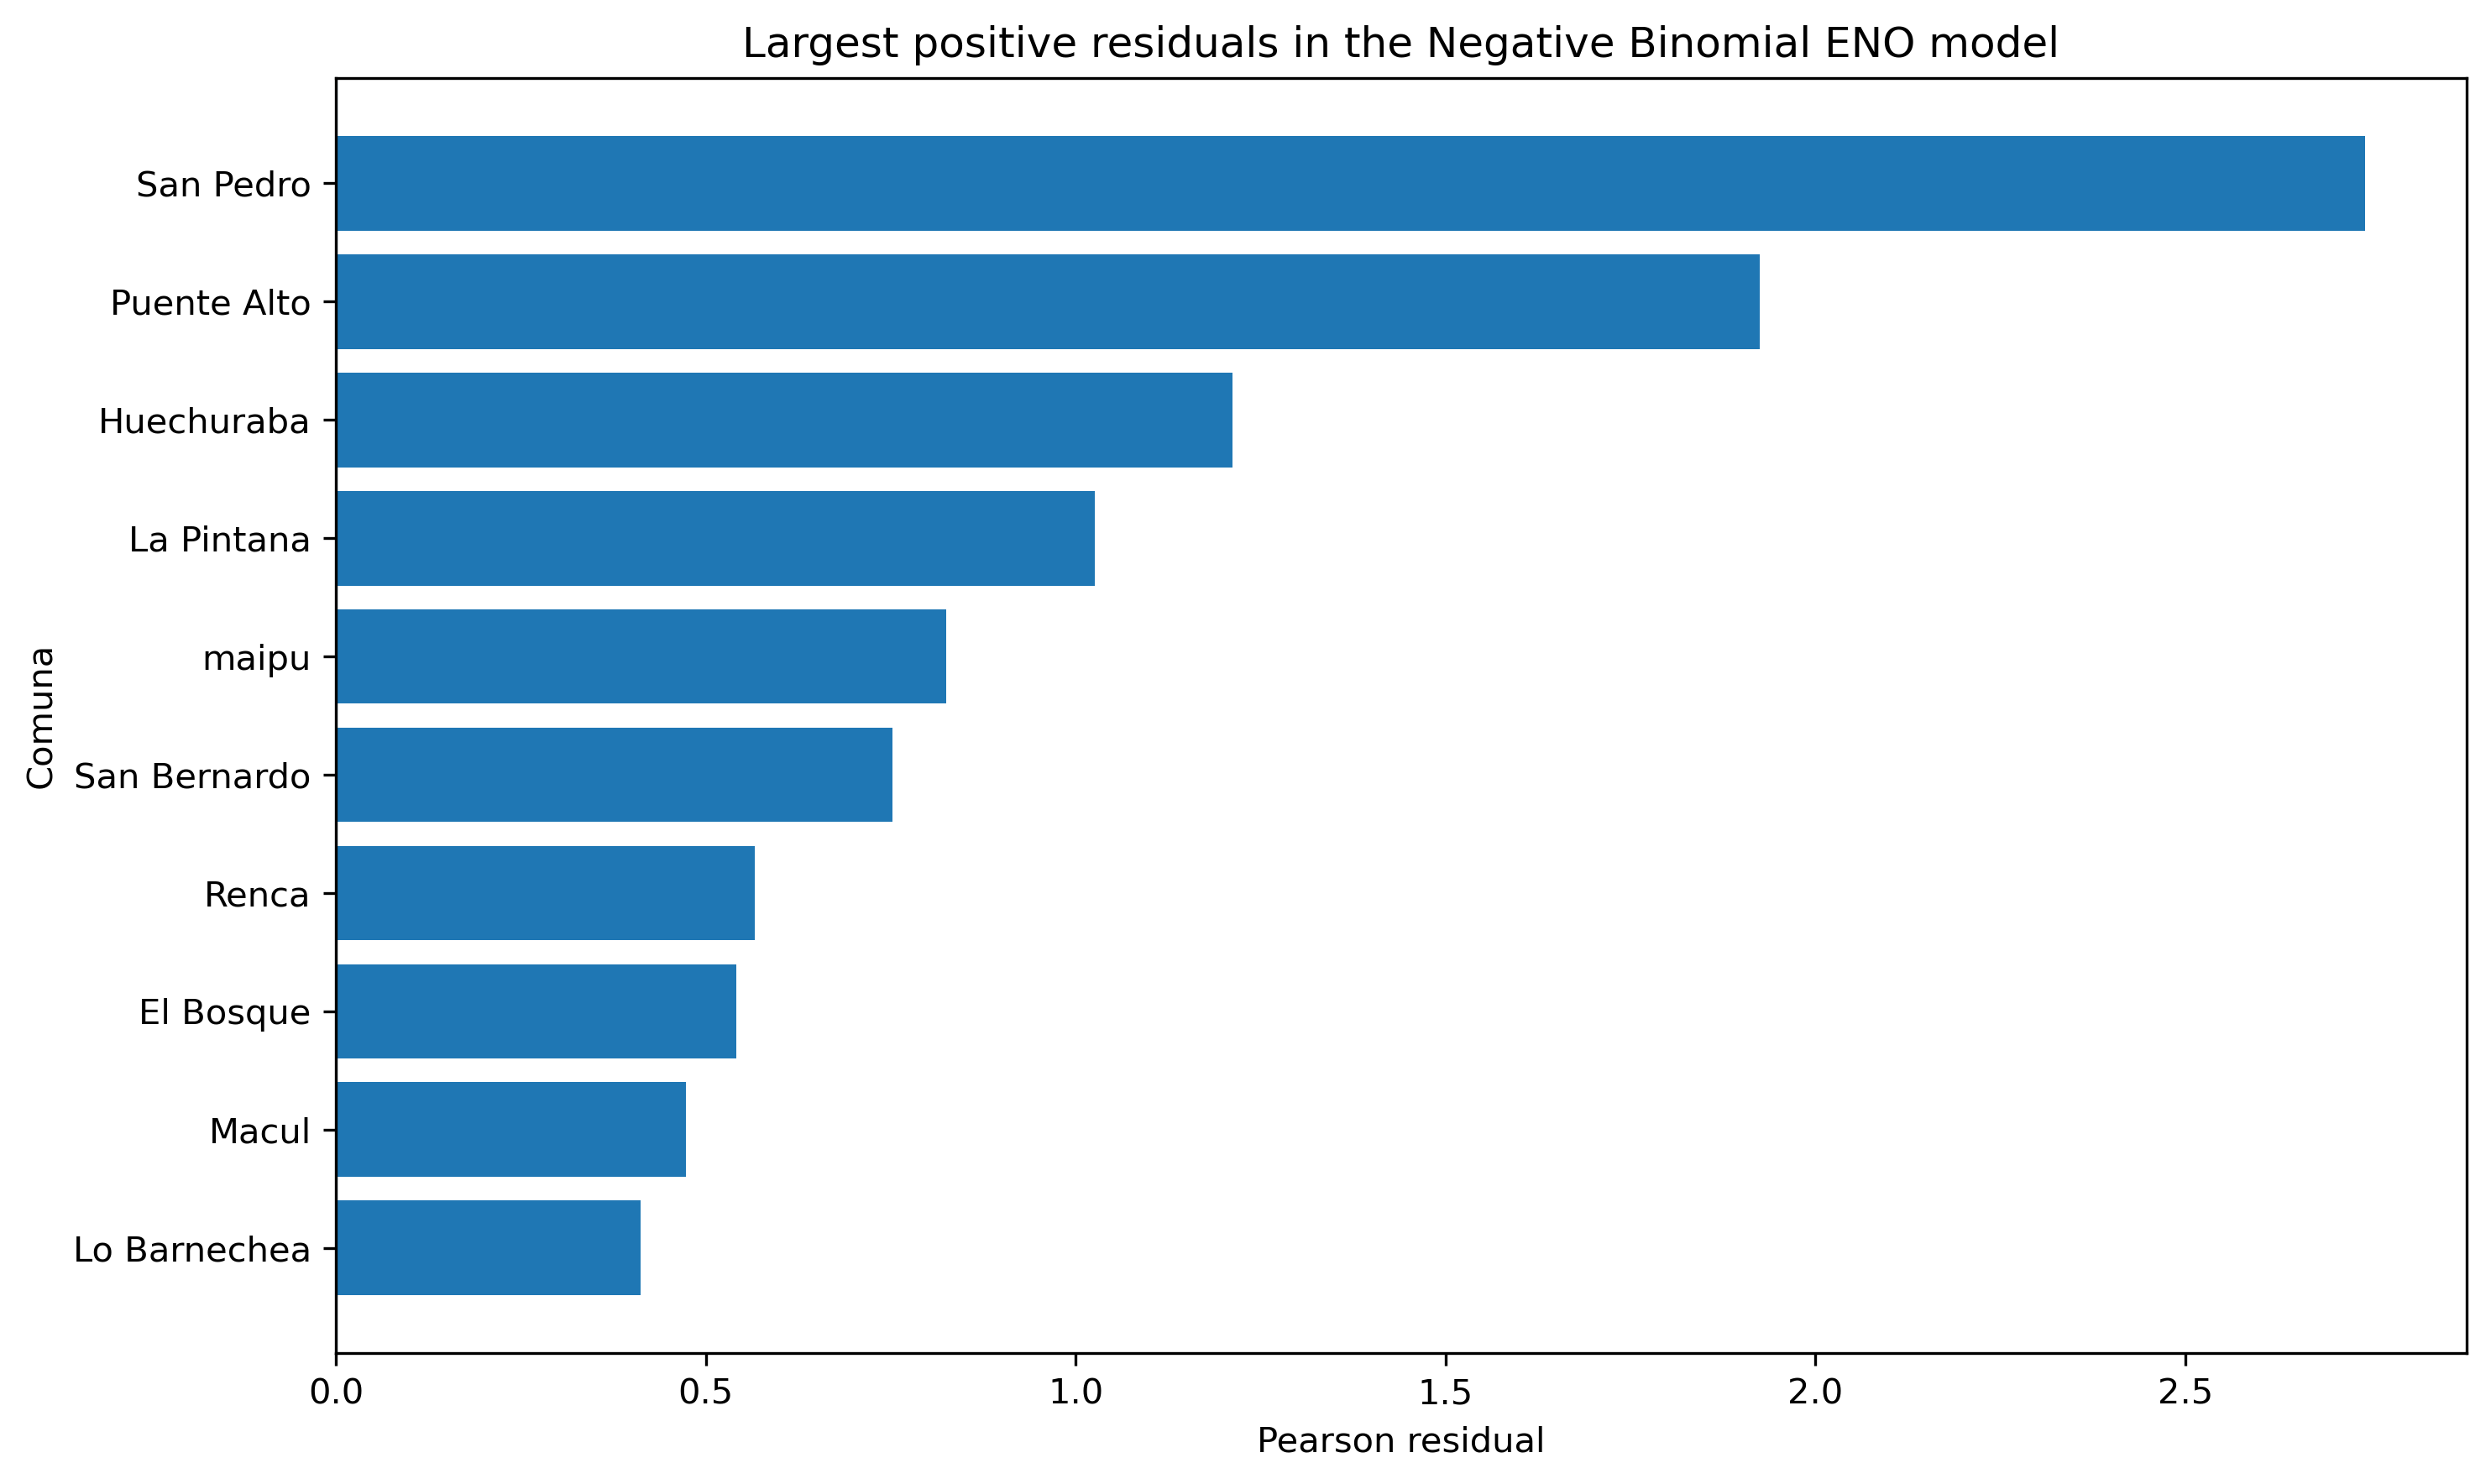

In [14]:
headline_path = figs_dir / "headline.png"

if headline_path.exists():
    display(Image(filename=str(headline_path), width=700))
else:
    plot_df = (
        residuals[["nombre_comuna", "pearson_residual"]]
        .sort_values("pearson_residual", ascending=False)
        .head(10)
        .copy()
    )

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["nombre_comuna"], plot_df["pearson_residual"])
    plt.gca().invert_yaxis()
    plt.axvline(0, linewidth=1)
    plt.xlabel("Residual Pearson")
    plt.ylabel("Comuna")
    plt.title("Mayores residuales positivos en el modelo ENO binomial negativo")
    plt.tight_layout()
    plt.show()

### 2. Contexto Tareas 1 y 2
Las primeras tareas nos sirvieron para construir la base del análisis. En la Tarea 1 trabajamos variables demográficas a nivel comuna, como población total, porcentaje de población extranjera, escolaridad y empleo. Luego, en la Tarea 2, construimos variables de salud relacionadas con ENO, como el total de notificaciones y tasas por población. Esto fue importante porque no queríamos mirar solo conteos brutos, ya que una comuna con más población naturalmente puede tener más casos.

In [15]:
context_cols = [
    "nombre_comuna",
    "pop_total",
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet",
    "eno_total"
]

communes_to_show = ["Colina", "Melipilla", "Talagante", "San Pedro"]

context_table = residuals[
    residuals["nombre_comuna"].isin(communes_to_show)
][context_cols].copy()

context_table = context_table.sort_values("nombre_comuna")

display(context_table.round(2))

,nombre_comuna,pop_total,pct_foreign,schooling_gap,employment_gap,pct_no_internet,eno_total
19,Colina,173293,13.09,-0.17,-10.05,32.58,1259
23,Melipilla,136325,8.17,-0.19,-15.45,42.53,824
26,San Pedro,11108,11.34,0.08,-15.42,78.47,731
27,Talagante,76429,6.01,-0.43,-9.99,31.84,314


### 3. Origen de la Anomalía
La anomalía aparece realmente en la Tarea 3, cuando unimos la información demográfica y de salud en una tabla analítica a nivel comuna. Con esa tabla se ajustaron modelos para explicar los conteos ENO. Como los datos presentaban más variabilidad de la que asume un modelo Poisson, se usó un modelo binomial negativo. Después comparamos los casos observados con los casos predichos por el modelo y calculamos los residuales.

In [16]:
eno_mean = residuals["eno_total"].mean()
eno_variance = residuals["eno_total"].var()
dispersion_ratio = eno_variance / eno_mean

dispersion_table = pd.DataFrame({
    "Métrica": [
        "Promedio de casos ENO",
        "Varianza de casos ENO",
        "Razón varianza sobre promedio"
    ],
    "Valor": [
        eno_mean,
        eno_variance,
        dispersion_ratio
    ]
})

display(dispersion_table.round(2))

,Métrica,Valor
0,Promedio de casos ENO,1053.34
1,Varianza de casos ENO,907515.91
2,Razón varianza sobre promedio,861.56


In [17]:
top_residuals = (
    residuals[
        [
            "nombre_comuna",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ]
    .sort_values("pearson_residual", ascending=False)
    .head(10)
    .copy()
)

top_residuals["Diferencia"] = (
    top_residuals["eno_total"] -
    top_residuals["predicted_eno_count"]
)

top_residuals = top_residuals[
    [
        "nombre_comuna",
        "eno_total",
        "predicted_eno_count",
        "Diferencia",
        "pearson_residual"
    ]
]

display(top_residuals.round(2))

,nombre_comuna,eno_total,predicted_eno_count,Diferencia,pearson_residual
26,San Pedro,731,346.81,384.19,2.74
17,Puente Alto,4334,2446.55,1887.45,1.92
2,Huechuraba,832,559.09,272.91,1.21
7,La Pintana,1507,1067.33,439.67,1.03
11,maipu,3316,2491.51,824.49,0.83
20,San Bernardo,2172,1668.50,503.50,0.75
15,Renca,1064,866.92,197.08,0.57
1,El Bosque,1212,995.54,216.46,0.54
10,Macul,890,747.85,142.15,0.47
8,Lo Barnechea,630,540.32,89.68,0.41


### 4. Chequeos Alternativos
#### 4.1 Chequeo 1:
El primer chequeo fue ver si San Pedro aparecía como anomalía solo por su tamaño poblacional. Esto era importante porque los conteos de casos pueden crecer simplemente porque una comuna tiene más habitantes. Sin embargo, el modelo ya considera la población, y aun así San Pedro queda muy por encima de lo esperado. Por eso, la anomalía no se explica solo por población.

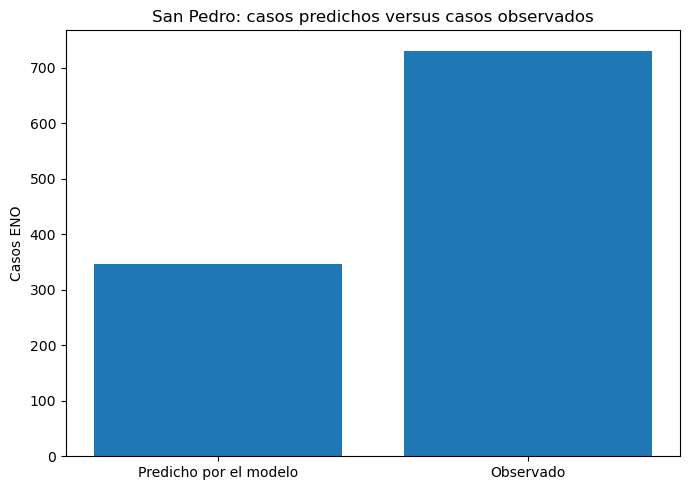

In [18]:
comparison_df = pd.DataFrame({
    "Tipo": ["Predicho por el modelo", "Observado"],
    "Casos ENO": [predicted, observed]
})

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Tipo"], comparison_df["Casos ENO"])
plt.ylabel("Casos ENO")
plt.title("San Pedro: casos predichos versus casos observados")
plt.tight_layout()
plt.show()

In [19]:
population_check = (
    residuals[
        [
            "nombre_comuna",
            "pop_total",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ]
    .sort_values("pearson_residual", ascending=False)
    .head(10)
    .copy()
)

population_check["Diferencia"] = (
    population_check["eno_total"] -
    population_check["predicted_eno_count"]
)

display(population_check.round(2))

,nombre_comuna,pop_total,eno_total,predicted_eno_count,pearson_residual,Diferencia
26,San Pedro,11108,731,346.81,2.74,384.19
17,Puente Alto,564477,4334,2446.55,1.92,1887.45
2,Huechuraba,101808,832,559.09,1.21,272.91
7,La Pintana,175421,1507,1067.33,1.03,439.67
11,maipu,500600,3316,2491.51,0.83,824.49
20,San Bernardo,306371,2172,1668.50,0.75,503.50
15,Renca,143622,1064,866.92,0.57,197.08
1,El Bosque,155257,1212,995.54,0.54,216.46
10,Macul,123800,890,747.85,0.47,142.15
8,Lo Barnechea,112620,630,540.32,0.41,89.68


#### 4.2 Chequeo 2:
El segundo chequeo fue revisar si San Pedro era muy distinto en las variables usadas por el modelo. Aquí sí vimos que San Pedro tiene un perfil particular. Por ejemplo, presenta el mayor porcentaje de personas sin internet fijo, una brecha de empleo muy marcada y el mayor schooling gap dentro de la tabla. Aun así, el modelo ya incluía estas variables y todavía predijo solo 346,81 casos, frente a 731 observados. Entonces, estas variables ayudan a describir San Pedro, pero no explican completamente la diferencia.

In [20]:
covariate_rows = []

for col in covariates:
    san_pedro_value = san_pedro[col].iloc[0]
    min_value = residuals[col].min()
    median_value = residuals[col].median()
    max_value = residuals[col].max()

    relative_position = (
        (san_pedro_value - min_value) /
        (max_value - min_value) * 100
    )

    covariate_rows.append({
        "Variable": col,
        "San Pedro": san_pedro_value,
        "Mínimo": min_value,
        "Mediana": median_value,
        "Máximo": max_value,
        "Posición relativa 0 a 100": relative_position
    })

covariate_check = pd.DataFrame(covariate_rows)

display(covariate_check.round(2))

,Variable,San Pedro,Mínimo,Mediana,Máximo,Posición relativa 0 a 100
0,pct_foreign,11.34,1.52,7.96,44.39,22.91
1,schooling_gap,0.08,-1.63,-0.82,0.08,100.00
2,employment_gap,-15.42,-15.45,-12.01,-8.12,0.39
3,pct_no_internet,78.47,15.54,30.02,78.47,100.00


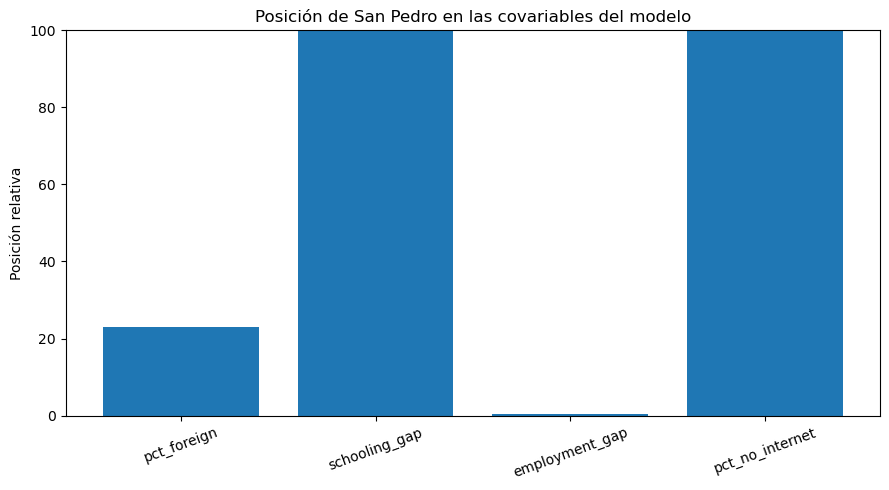

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(
    covariate_check["Variable"],
    covariate_check["Posición relativa 0 a 100"]
)
plt.ylim(0, 100)
plt.ylabel("Posición relativa")
plt.title("Posición de San Pedro en las covariables del modelo")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5. Significado
Este resultado puede servir como una alerta para revisar San Pedro con más detalle. No significa automáticamente que San Pedro tenga peores condiciones de salud en general, ni que una variable específica cause los casos ENO. Lo que sí muestra es que, bajo el modelo construido, San Pedro tuvo muchos más casos de los que se esperaban.

In [22]:
pd.set_option('display.max_colwidth', None)

meaning_table = pd.DataFrame({
    "Lo que el resultado sugiere": [
        "San Pedro debería revisarse con más detalle",
        "Puede existir un patrón local no capturado completamente por el modelo",
        "Conviene revisar los casos por enfermedad y periodo"
    ],
    "Lo que no permite afirmar": [
        "No prueba causalidad",
        "No permite decir que una variable específica causó el exceso de casos",
        "No permite sacar conclusiones sobre personas individuales"
    ]
})

display(meaning_table)

,Lo que el resultado sugiere,Lo que no permite afirmar
0,San Pedro debería revisarse con más detalle,No prueba causalidad
1,Puede existir un patrón local no capturado completamente por el modelo,No permite decir que una variable específica causó el exceso de casos
2,Conviene revisar los casos por enfermedad y periodo,No permite sacar conclusiones sobre personas individuales


### 6. Límites y Próximos Pasos
La principal limitación es que trabajamos con datos a nivel comuna, no a nivel individual. Por eso no podemos afirmar causalidad ni decir qué le ocurre a una persona específica. Con una semana más, revisaríamos los casos de San Pedro por tipo de enfermedad y por periodo, para ver si el exceso viene de una enfermedad puntual, de un año específico o de un patrón más general de notificación.

In [23]:
pd.set_option('display.max_colwidth', None)

next_steps = pd.DataFrame({
    "Límite actual": [
        "El análisis está a nivel comuna",
        "No se revisa cada enfermedad por separado",
        "No se analiza el momento exacto de los casos",
        "No se incluyen variables locales de acceso o reporte en salud"
    ],
    "Próximo paso": [
        "Evitar conclusiones individuales",
        "Revisar qué enfermedades explican el exceso",
        "Separar los casos por año o periodo",
        "Incorporar información local sobre acceso, reporte o servicios de salud"
    ]
})

display(next_steps)

,Límite actual,Próximo paso
0,El análisis está a nivel comuna,Evitar conclusiones individuales
1,No se revisa cada enfermedad por separado,Revisar qué enfermedades explican el exceso
2,No se analiza el momento exacto de los casos,Separar los casos por año o periodo
3,No se incluyen variables locales de acceso o reporte en salud,"Incorporar información local sobre acceso, reporte o servicios de salud"
